<a href="https://colab.research.google.com/github/18felasofa/Analisis-Deret-Waktu/blob/main/analisis_arima_soetta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Deret Waktu Box-Jenkins (ARIMA) — Penumpang Soekarno-Hatta

Pipeline: **Preprocessing → Uji Kestasioneran → Identifikasi (EACF) → Estimasi → Diagnostik Sisaan → Evaluasi Out-of-Sample & Rolling CV → Forecast**.

### Ringkasan perbaikan dari kode asli
| # | Masalah pada kode asli | Perbaikan |
|---|---|---|
| 1 | **EACF salah**: rekursi `res[(k-1, j-1)]` tidak menghasilkan pola segitiga yang benar (uji simulasi ARMA(1,1) memberi puncak di AR=2, bukan (1,1)) | Diganti dengan regresi iteratif Tsay–Tiao; sudah dicek pada data simulasi AR(1), MA(1), ARMA(1,1), ARMA(1,2) |
| 2 | `max_d = ceil(sqrt(n))` → diferensiasi bisa sampai belasan kali (over-differencing, model meledak/NaN) | `MAX_D = 2` (bisa diubah di sel konfigurasi) |
| 3 | Residual `d` observasi pertama ARIMA bernilai sangat besar (inisialisasi difus) dan ikut masuk uji diagnostik | Dibuang dengan `resid.iloc[d:]` |
| 4 | Uji signifikansi parameter ikut menguji `sigma2` | `sigma2` dikeluarkan |
| 5 | `if self.boxcox_lambda:` salah untuk λ = 0 (transformasi log) | Diganti `is not None` |
| 6 | Forecast masa depan dimulai dari akhir **data latih** (menumpuk dengan periode uji) | Model di-refit pada data latih + uji (`full_series`) |
| 7 | CV: MASE memakai skala data hasil Box-Cox, sedangkan galat di skala asli; kebenaran (truth) memakai data yang sudah di-cap | Memakai data asli untuk truth dan MASE; refit hanya sekali per order unik |
| 8 | Laporan EDA hanya ditulis ke file, semua grafik di-`close` tanpa ditampilkan | Laporan di-print, grafik ditampilkan inline (`show_plots`) |
| 9 | Plot forecast masa depan mencampur indeks tanggal dan indeks integer | Indeks masa depan dibangun dari indeks data (`make_future_index`) |
| 10 | Loop *retry* bisa mengulang kandidat yang sama, `_fit_candidates` error bila semua fit gagal, `plot_pacf` error bila lag > n/2 | Deteksi kandidat berulang, guard error, lag dibatasi |
| 11 | Kode simpan gambar berulang-ulang, plot duplikat untuk tiap kriteria | Helper `_finish_fig` dan pengelompokan model per order |

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm, boxcox, boxcox_llf, shapiro
from scipy.special import inv_boxcox
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tools.sm_exceptions import ConvergenceWarning

try:
    from IPython.display import display
except ImportError:          # bila dijalankan sebagai skrip biasa
    display = print

warnings.simplefilter("ignore", ConvergenceWarning)
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

## 0. Konfigurasi

In [2]:
URL = "https://raw.githubusercontent.com/lailynissa/tsapython/main/penumpang%20soeta.csv"
KOLOM_TARGET = "Total"      # nama kolom nilai yang dianalisis
TRAIN_RATIO = 0.95          # proporsi data latih
MAX_D = 2                   # batas maksimum diferensiasi (d > 2 hampir tidak pernah wajar)
BASE_P, BASE_Q = 7, 7       # batas awal ruang pencarian EACF
MAX_RETRIES = 3             # jumlah percobaan perluasan ruang pencarian
SEASONAL_PERIOD = 12        # periode musiman untuk dekomposisi EDA (12 = data bulanan)
OUTPUT_DIR = "output"       # folder penyimpanan gambar & laporan
SHOW_PLOTS = True           # tampilkan grafik di notebook

## 1. Helper metrik & visualisasi EDA

In [3]:
def calculate_accuracy_metrics(y_true, y_pred, y_train=None):
    """MAE, RMSE, MAPE, sMAPE, dan MASE (bila y_train diberikan)."""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    errors = y_true - y_pred
    abs_errors = np.abs(errors)
    mae, rmse = np.mean(abs_errors), np.sqrt(np.mean(errors ** 2))

    mask = y_true != 0
    mape = np.mean(abs_errors[mask] / np.abs(y_true[mask])) * 100 if np.any(mask) else np.nan

    denom = np.abs(y_true) + np.abs(y_pred)
    s_mask = denom != 0
    smape = np.mean(200 * abs_errors[s_mask] / denom[s_mask]) if np.any(s_mask) else np.nan

    mase = np.nan
    if y_train is not None and len(y_train) > 1:
        naive_mae = np.nanmean(np.abs(np.diff(np.asarray(y_train, float))))
        if naive_mae and not np.isnan(naive_mae):
            mase = mae / naive_mae

    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "sMAPE (%)": smape, "MASE": mase}


def make_future_index(index, steps):
    """Bangun indeks untuk `steps` periode setelah akhir `index` (tanggal atau angka)."""
    if isinstance(index, pd.DatetimeIndex):
        freq = index.freq
        if freq is None and len(index) >= 3:
            freq = pd.infer_freq(index)
        if freq is not None:
            return pd.date_range(start=index[-1], periods=steps + 1, freq=freq)[1:]
        step = pd.Series(index).diff().median()
        return pd.DatetimeIndex([index[-1] + step * (i + 1) for i in range(steps)])
    try:
        last = index[-1]
        return pd.Index([last + i + 1 for i in range(steps)])
    except Exception:
        return pd.RangeIndex(len(index), len(index) + steps)

In [4]:
def plot_eda(series, lags=20, title="Eksplorasi Data Deret Waktu (EDA)", save_dir=None,
             seasonal_period=12, show=True):
    """Uji stasioneritas (ADF/KPSS), Box-Cox, plot deret, ACF/PACF, dekomposisi, dan lag plot."""
    series = pd.Series(series).astype(float)
    lags = max(1, min(lags, len(series) // 2 - 1))
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    def finish(fig, filename):
        if save_dir:
            try:
                fig.savefig(os.path.join(save_dir, filename), bbox_inches="tight")
            except OSError as e:
                print(f"   [!] Gagal menyimpan {filename}: {e}")
        if show:
            plt.show()
        plt.close(fig)

    # --- 1. Uji stasioneritas dalam nilai tengah ---
    adf_p = adfuller(series, autolag="AIC")[1]
    kpss_p = kpss(series, regression="c", nlags="auto")[1]

    report = ["=" * 50, "LAPORAN EKSPLORASI DATA DERET WAKTU (EDA)", "=" * 50,
              "\n[1] Uji Stasioneritas dalam Nilai Tengah:",
              f"  - ADF Test (H0: Tidak stasioner): p-value = {adf_p:.4f} -> {'Stasioner' if adf_p < 0.05 else 'Tidak Stasioner'}",
              f"  - KPSS Test (H0: Stasioner): p-value = {kpss_p:.4f} -> {'Tidak Stasioner' if kpss_p < 0.05 else 'Stasioner'}"]

    # --- 2. Box-Cox (stasioneritas dalam ragam) ---
    try:
        if (series > 0).all():
            _, lambda_fit, ci = boxcox(series.values, alpha=0.05)
            lambda_one_in_ci = ci[0] <= 1 <= ci[1]
            report += ["\n[2] Uji Stasioneritas dalam Ragam (Box-Cox Transformation):",
                       f"  - Nilai Lambda Optimum: {lambda_fit:.4f}",
                       f"  - 95% Confidence Interval: ({ci[0]:.4f}, {ci[1]:.4f})",
                       f"  - Apakah Lambda=1 dalam CI? {'Ya (Tidak perlu transformasi)' if lambda_one_in_ci else 'Tidak (Perlu transformasi)'}"]

            lambdas = np.linspace(-2, 3, 100)
            llf = [boxcox_llf(l, series.values) for l in lambdas]
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.plot(lambdas, llf, lw=2)
            ax.axvline(lambda_fit, color="r", linestyle="--", label=f"Optimal Lambda: {lambda_fit:.2f}")
            ax.axvline(1, color="green", linestyle="-.", label="Lambda = 1 (No Transform)")
            ax.axvspan(ci[0], ci[1], color="orange", alpha=0.3, label=f"95% CI: ({ci[0]:.2f}, {ci[1]:.2f})")
            ax.set(xlabel="Lambda", ylabel="Log-Likelihood Function",
                   title=f"Box-Cox Transformation Plot\nLambda=1 dalam CI? {'Ya' if lambda_one_in_ci else 'Tidak'}")
            ax.legend()
            ax.grid(True)
            finish(fig, "01_BoxCox_Transformation.png")
        else:
            report.append("\n[2] Uji Stasioneritas dalam Ragam: Dilewati (Terdapat nilai <= 0)")
    except Exception as e:
        report.append(f"\n[2] Uji Stasioneritas dalam Ragam: Gagal ({e})")

    print("\n".join(report))
    if save_dir:
        with open(os.path.join(save_dir, "EDA_Report.txt"), "w", encoding="utf-8") as f:
            f.write("\n".join(report))

    # --- 3. Plot deret waktu ---
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(series.index, series.values, label="Observasi")
    ax.set(title=f"{title} - Time Series", xlabel="Waktu", ylabel="Nilai")
    ax.legend()
    finish(fig, "02_TimeSeries_Plot.png")

    # --- 4. ACF & PACF ---
    fig, (ax_acf, ax_pacf) = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(series, lags=lags, ax=ax_acf, alpha=0.05)
    plot_pacf(series, lags=lags, ax=ax_pacf, alpha=0.05)
    ax_acf.set_title("Autocorrelation Function (ACF)")
    ax_pacf.set_title("Partial Autocorrelation (PACF)")
    plt.tight_layout()
    finish(fig, "03_ACF_PACF.png")

    # --- 5. Dekomposisi musiman ---
    period = seasonal_period if len(series) >= 2 * seasonal_period else (4 if len(series) >= 8 else 2)
    try:
        decomp = seasonal_decompose(series, model="additive", period=period)
        fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
        axes[0].plot(series.index, decomp.trend, color="orange")
        axes[0].set_title(f"Komponen Tren (Dekomposisi Aditif, period={period})")
        axes[1].plot(series.index, decomp.seasonal, color="green")
        axes[1].set_title("Komponen Musiman (Seasonality)")
        axes[2].plot(series.index, decomp.resid, color="red")
        axes[2].set_title("Komponen Sisaan (Residuals)")
        plt.tight_layout()
        finish(fig, "04_Seasonal_Decomposition.png")
    except Exception as e:
        print(f"[!] Dekomposisi musiman dilewati: {e}")

    # --- 6. Lag plot ---
    fig, ax = plt.subplots(figsize=(6, 6))
    pd.plotting.lag_plot(series, ax=ax, c="purple", alpha=0.6)
    ax.set_title("Lag Plot (Y_t vs Y_{t-1})")
    finish(fig, "05_Lag_Plot.png")

class DynamicTimeSeriesPreprocessor:
    """Imputasi NA, capping outlier (IQR), dan Box-Cox otomatis (dengan inversinya)."""

    def __init__(self, handle_outliers=True, iqr_multiplier=1.5, auto_boxcox=False):
        self.handle_outliers = handle_outliers
        self.iqr_multiplier = iqr_multiplier
        self.auto_boxcox = auto_boxcox
        self.boxcox_lambda = None      # None = tanpa transformasi
        self.shift_constant = 0.0
        self.lower_bound = None
        self.upper_bound = None

    @staticmethod
    def _as_series(series):
        return series.iloc[:, 0].copy() if isinstance(series, pd.DataFrame) else series.copy()

    def preprocess(self, series):
        """Fit parameter preprocessing pada data latih, lalu kembalikan data yang sudah diproses."""
        s = self._as_series(series)
        print("\n[ TAHAP 0: PREPROCESSING ]")

        if s.isna().any():
            s = s.interpolate(method="linear").bfill().ffill()
            print(" -> Missing values terimputasi.")

        if self.handle_outliers:
            q1, q3 = s.quantile(0.25), s.quantile(0.75)
            bound = self.iqr_multiplier * (q3 - q1)
            self.lower_bound, self.upper_bound = q1 - bound, q3 + bound
            n_out = int(((s < self.lower_bound) | (s > self.upper_bound)).sum())
            s = s.clip(lower=self.lower_bound, upper=self.upper_bound)
            print(f" -> Outliers di-cap berbasis IQR ({n_out} titik).")

        if self.auto_boxcox:
            self.shift_constant = abs(s.min()) + 1.0 if s.min() <= 0 else 0.0
            tx, lmbda = boxcox(s + self.shift_constant)
            if abs(lmbda - 1.0) < 0.1:
                self.boxcox_lambda = None
                print(f" -> Box-Cox tidak diperlukan (Lambda={lmbda:.4f} ~ 1).")
            else:
                self.boxcox_lambda = lmbda
                s = pd.Series(tx, index=s.index)
                print(f" -> Box-Cox diterapkan (Lambda={lmbda:.4f}).")
        return s

    def transform(self, series):
        """Terapkan preprocessing yang SUDAH di-fit pada data baru (mis. data latih + uji)."""
        s = self._as_series(series)
        if s.isna().any():
            s = s.interpolate(method="linear").bfill().ffill()
        if self.handle_outliers and self.lower_bound is not None:
            s = s.clip(lower=self.lower_bound, upper=self.upper_bound)
        if self.boxcox_lambda is not None:
            shifted = np.maximum(s.values + self.shift_constant, 1e-6)   # Box-Cox butuh nilai > 0
            s = pd.Series(boxcox(shifted, lmbda=self.boxcox_lambda), index=s.index)
        return s

    def inverse_transform(self, vals):
        vals = np.asarray(vals, float)
        if self.boxcox_lambda is None:
            return vals
        # Clip values to ensure they are non-negative for inverse Box-Cox
        # using a small epsilon to avoid issues with zero values if lambda is not 0
        clipped_vals = np.maximum(vals, 1e-6)
        return inv_boxcox(clipped_vals, self.boxcox_lambda) - self.shift_constant

In [5]:
class DynamicTimeSeriesPreprocessor:
    """Imputasi NA, capping outlier (IQR), dan Box-Cox otomatis (dengan inversinya)."""

    def __init__(self, handle_outliers=True, iqr_multiplier=1.5, auto_boxcox=False):
        self.handle_outliers = handle_outliers
        self.iqr_multiplier = iqr_multiplier
        self.auto_boxcox = auto_boxcox
        self.boxcox_lambda = None      # None = tanpa transformasi
        self.shift_constant = 0.0
        self.lower_bound = None
        self.upper_bound = None

    @staticmethod
    def _as_series(series):
        return series.iloc[:, 0].copy() if isinstance(series, pd.DataFrame) else series.copy()

    def preprocess(self, series):
        """Fit parameter preprocessing pada data latih, lalu kembalikan data yang sudah diproses."""
        s = self._as_series(series)
        print("\n[ TAHAP 0: PREPROCESSING ]")

        if s.isna().any():
            s = s.interpolate(method="linear").bfill().ffill()
            print(" -> Missing values terimputasi.")

        if self.handle_outliers:
            q1, q3 = s.quantile(0.25), s.quantile(0.75)
            bound = self.iqr_multiplier * (q3 - q1)
            self.lower_bound, self.upper_bound = q1 - bound, q3 + bound
            n_out = int(((s < self.lower_bound) | (s > self.upper_bound)).sum())
            s = s.clip(lower=self.lower_bound, upper=self.upper_bound)
            print(f" -> Outliers di-cap berbasis IQR ({n_out} titik).")

        if self.auto_boxcox:
            self.shift_constant = abs(s.min()) + 1.0 if s.min() <= 0 else 0.0
            tx, lmbda = boxcox(s + self.shift_constant)
            if abs(lmbda - 1.0) < 0.1:
                self.boxcox_lambda = None
                print(f" -> Box-Cox tidak diperlukan (Lambda={lmbda:.4f} ~ 1).")
            else:
                self.boxcox_lambda = lmbda
                s = pd.Series(tx, index=s.index)
                print(f" -> Box-Cox diterapkan (Lambda={lmbda:.4f}).")
        return s

    def transform(self, series):
        """Terapkan preprocessing yang SUDAH di-fit pada data baru (mis. data latih + uji)."""
        s = self._as_series(series)
        if s.isna().any():
            s = s.interpolate(method="linear").bfill().ffill()
        if self.handle_outliers and self.lower_bound is not None:
            s = s.clip(lower=self.lower_bound, upper=self.upper_bound)
        if self.boxcox_lambda is not None:
            shifted = np.maximum(s.values + self.shift_constant, 1e-6)   # Box-Cox butuh nilai > 0
            s = pd.Series(boxcox(shifted, lmbda=self.boxcox_lambda), index=s.index)
        return s

    def inverse_transform(self, vals):
        vals = np.asarray(vals, float)
        if self.boxcox_lambda is None:
            return vals
        return inv_boxcox(vals, self.boxcox_lambda) - self.shift_constant

In [6]:
def _acf_at_lag(x, lag):
    """Autokorelasi sampel pada lag tertentu (NaN diabaikan)."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    if len(x) <= lag + 1:
        return np.nan
    x = x - x.mean()
    return np.dot(x[:-lag], x[lag:]) / np.dot(x, x)


def _lag(x, l):
    out = np.full(len(x), np.nan)
    out[l:] = x[:-l]
    return out


def calculate_eacf(series, ar_max=5, ma_max=5):
    """
    Extended ACF (Tsay & Tiao) dengan regresi AR iteratif.

    Untuk setiap orde AR k, iterasi ke-j meregresikan Z_t pada Z_{t-1..t-k} dan
    W_{t-1}^{(k,j-1)}, ..., W_{t-j}^{(k,0)} (sisaan dari iterasi sebelumnya).
    Sel (k, j) = autokorelasi lag j+1 dari W^{(k,j)} = Z_t - sum(phi_i Z_{t-i}).
    'o' = tidak signifikan (nol), 'x' = signifikan. Puncak segitiga 'o' -> ARMA(p, q).
    """
    z = np.asarray(series, float)
    z = z[~np.isnan(z)]
    n = len(z)
    z = z - z.mean()

    mat = np.full((ar_max + 1, ma_max + 1), np.nan)
    for k in range(ar_max + 1):
        z_lags = [_lag(z, i) for i in range(1, k + 1)]
        W = []
        for j in range(ma_max + 1):
            if k == 0:
                w = z.copy()
            else:
                cols = z_lags + [_lag(W[j - l], l) for l in range(1, j + 1)]
                X = np.column_stack(cols)
                ok = ~np.isnan(X).any(axis=1)
                if ok.sum() <= X.shape[1]:
                    W.append(np.full(n, np.nan))
                    continue
                beta = np.linalg.lstsq(X[ok], z[ok], rcond=None)[0]
                w = z - np.column_stack(z_lags) @ beta[:k]     # NaN pada k observasi awal
            W.append(w)
            mat[k, j] = _acf_at_lag(w, j + 1)

    bound = norm.ppf(0.975) / np.sqrt(np.maximum(n - np.arange(ar_max + 1)[:, None] - np.arange(ma_max + 1), 1))
    symbols = np.where(np.isnan(mat), "-", np.where(np.abs(mat) > bound, "x", "o"))
    return pd.DataFrame(symbols, index=[f"AR {k}" for k in range(ar_max + 1)],
                        columns=[f"MA {j}" for j in range(ma_max + 1)])


def extract_eacf_candidates(df_eacf, top_n=5):
    """Ambil kandidat (p, q) dari puncak segitiga 'o' pada tabel EACF."""
    mat = (df_eacf.values == "o")
    n_rows, n_cols = mat.shape
    candidates = []

    for p in range(n_rows):
        for q in range(n_cols):
            if not mat[p, q]:
                continue
            # Aturan segitiga: baris p+k harus 'o' mulai kolom q+k sampai akhir, untuk semua k >= 0
            is_triangle = all(
                mat[p + k, min(q + k, n_cols - 1):].all() for k in range(n_rows - p)
            )
            if is_triangle:
                candidates.append((p, q))

    if not candidates:
        return (0, 0), [(0, 0)]
    candidates = sorted(candidates, key=lambda x: (x[0] + x[1], x[1]))
    return candidates[0], candidates[:top_n]

## 3. Analyzer utama (Box-Jenkins)

In [7]:
class BoxJenkinsAnalyzer:
    def __init__(self, preprocessor=None, max_d=2, alpha=0.05, max_p=7, max_q=7,
                 output_dir="output", show_plots=True, seasonal_period=12):
        self.preprocessor = preprocessor or DynamicTimeSeriesPreprocessor()
        self.max_d, self.alpha = int(max_d), alpha
        self.max_p, self.max_q = max_p, max_q
        self.output_dir = output_dir
        self.show_plots = show_plots
        self.seasonal_period = seasonal_period

        self.raw_series = None
        self.clean_series = None
        self.stationary_series = None
        self.d_estimated = 0
        self.candidates = []
        self.best_orders = {}
        self.best_models = {}
        os.makedirs(self.output_dir, exist_ok=True)

    # ------------------------------------------------------------------ util
    def _finish_fig(self, fig, filename, criteria=None):
        """Simpan gambar ke folder tiap kriteria, tampilkan (opsional), lalu tutup."""
        for crit in (criteria or []):
            crit_dir = os.path.join(self.output_dir, crit)
            os.makedirs(crit_dir, exist_ok=True)
            path = os.path.join(crit_dir, filename)
            try:
                fig.savefig(path, bbox_inches="tight")
            except OSError as e:
                print(f"   [!] Gagal menyimpan {path} (file mungkin sedang dibuka): {e}")
        if self.show_plots:
            plt.show()
        plt.close(fig)

    def _group_by_order(self):
        """Kelompokkan kriteria yang memilih model (order) yang sama."""
        groups = {}
        for crit, order in self.best_orders.items():
            g = groups.setdefault(order, {"criteria": [], "model": self.best_models[crit]})
            g["criteria"].append(crit)
        return groups

    # ------------------------------------------------- kestasioneran & batas
    def _difference_until_stationary(self, s):
        def test(x):
            return adfuller(x)[1], kpss(x, regression="c", nlags="auto")[1]

        d, current = 0, s.copy()
        if self.max_d > 0:
            p_adf, p_kpss = test(current)
            while (p_adf > self.alpha or p_kpss < self.alpha) and d < self.max_d:
                d += 1
                current = current.diff().dropna()
                p_adf, p_kpss = test(current)
        return d, current

    def _estimate_adaptive_bounds(self, s):
        conf = 1.96 / np.sqrt(len(s))
        nlags = max(1, min(max(20, self.max_p, self.max_q), len(s) // 2 - 1))
        acf_v = acf(s, nlags=nlags, fft=False)
        pacf_v = pacf(s, nlags=nlags, method="yw")

        last_sig_acf = next((lag for lag in range(nlags, 0, -1) if abs(acf_v[lag]) > conf), 0)
        last_sig_pacf = next((lag for lag in range(nlags, 0, -1) if abs(pacf_v[lag]) > conf), 0)
        self.max_q = max(1, min(self.max_q, last_sig_acf))     # MA dari ACF
        self.max_p = max(1, min(self.max_p, last_sig_pacf))    # AR dari PACF
        print(f" -> Adaptive Bounds: max_p={self.max_p}, max_q={self.max_q}")

    # --------------------------------------------------------------- pipeline
    def run_pipeline(self, series, show_eda=False):
        self.raw_series = series.iloc[:, 0].copy() if isinstance(series, pd.DataFrame) else series.copy()
        self.clean_series = self.preprocessor.preprocess(self.raw_series)

        print("\n[ TAHAP 1: KESTASIONERAN & IDENTIFIKASI ]")
        self.d_estimated, self.stationary_series = self._difference_until_stationary(self.clean_series)
        print(f" -> Diferensiasi Terpilih: d = {self.d_estimated}")
        self._estimate_adaptive_bounds(self.stationary_series)

        if show_eda:
            plot_eda(self.raw_series, title="EDA Data Asli (Sebelum Preprocessing)",
                     save_dir=os.path.join(self.output_dir, "EDA"),
                     seasonal_period=self.seasonal_period, show=self.show_plots)

        print("\n[ TAHAP 2: ESTIMASI PARAMETER (EACF) ]")
        df_eacf = calculate_eacf(self.stationary_series, self.max_p, self.max_q)
        display(df_eacf)
        _, self.candidates = extract_eacf_candidates(df_eacf)
        print(f" -> Kandidat: {self.candidates}")

        self._fit_candidates(self.candidates)
        return self

    def _fit_candidates(self, candidates):
        results, models = [], {}
        for p, q in candidates:
            order = (p, self.d_estimated, q)
            try:
                res = ARIMA(self.clean_series, order=order).fit()
                models[order] = res
                results.append({"Order": order, "AIC": res.aic, "BIC": res.bic,
                                "AICc": res.aicc, "HQIC": res.hqic, "LOGLIKE": res.llf})
            except Exception as e:
                print(f"   [!] ARIMA{order} gagal di-fit: {e}")

        if not results:
            raise RuntimeError("Semua kandidat model gagal di-fit.")

        df_res = pd.DataFrame(results)
        print("\n[ REKAPITULASI METRIK ]")
        display(df_res)

        for crit in ["AIC", "BIC", "AICc", "HQIC"]:
            self.best_orders[crit] = df_res.loc[df_res[crit].idxmin(), "Order"]
            self.best_models[crit] = models[self.best_orders[crit]]
        self.best_orders["LOGLIKE"] = df_res.loc[df_res["LOGLIKE"].idxmax(), "Order"]
        self.best_models["LOGLIKE"] = models[self.best_orders["LOGLIKE"]]

    # ------------------------------------------------------------ diagnostik
    def diagnostics(self):
        print("\n" + "=" * 80)
        print("[ TAHAP 3: DIAGNOSTIK SISAAN (KOMPREHENSIF) ]")
        print("=" * 80)

        any_passed = False
        for order, data in self._group_by_order().items():
            crits, model, crit_list = ", ".join(data["criteria"]), data["model"], data["criteria"]
            p, d, q = order

            # d observasi pertama pada ARIMA (d>0) memakai inisialisasi difus -> sisaan tidak valid
            resids = model.resid.iloc[d:].dropna()

            model_df = p + q
            lb_lags = max(10, model_df + 5)
            arch_lags = max(1, min(10, len(resids) // 3))

            # 1. Ljung-Box
            lb_res = acorr_ljungbox(resids, lags=[lb_lags], model_df=model_df, return_df=True)
            lb_stat, lb_p = lb_res["lb_stat"].iloc[0], lb_res["lb_pvalue"].iloc[0]

            # 2. Normalitas
            sw_stat, sw_p = shapiro(resids)
            jb_stat, jb_p, skew, kurt = jarque_bera(resids)

            # 3. Heteroskedastisitas
            arch_stat, arch_p = het_arch(resids, nlags=arch_lags)[:2]
            bp_stat, bp_p, _, _ = het_breuschpagan(resids, sm.add_constant(np.arange(len(resids))))

            # 4. Signifikansi parameter (sigma2 bukan parameter model ARMA -> dikeluarkan)
            pvals = model.pvalues.drop("sigma2", errors="ignore")
            insig_params = pvals[pvals > self.alpha]

            def conclude(pval):
                return "TOLAK H0" if pval < self.alpha else "GAGAL TOLAK H0"

            hetero = arch_p < self.alpha or bp_p < self.alpha

            print(f"\n>> MODEL: ARIMA{order} (Dipilih oleh: {crits})")
            print("-" * 80)
            print("1. UJI AUTOKORELASI (Ljung-Box Test)")
            print("   [H0: Residual saling bebas | H1: Terdapat autokorelasi]")
            print(f"   - Setup      : Lags={lb_lags}, Model_DF={model_df}")
            print(f"   - Statistik  : Q = {lb_stat:.4f}, P-Value = {lb_p:.4f}")
            print(f"   - Kesimpulan : {conclude(lb_p)} -> {'Terdapat sisaan autokorelasi (Gagal)' if lb_p < self.alpha else 'Residual saling bebas (Lolos)'}")

            print("\n2. UJI NORMALITAS (Shapiro-Wilk & Jarque-Bera)")
            print("   [H0: Residual berdistribusi normal | H1: Residual tidak berdistribusi normal]")
            print(f"   - Shapiro-W  : W = {sw_stat:.4f}, P-Value = {sw_p:.4f} -> {conclude(sw_p)}")
            print(f"   - Jarque-Bera: JB = {jb_stat:.4f}, P-Value = {jb_p:.4f} -> {conclude(jb_p)}")
            print(f"   - Momen      : Skewness = {skew:.4f}, Kurtosis = {kurt:.4f}")

            print("\n3. UJI HOMOSKEDASTISITAS (ARCH-LM & Breusch-Pagan)")
            print("   [H0: Varians residual konstan | H1: Varians residual tidak konstan (Heteroskedastisitas)]")
            print(f"   - ARCH-LM    (Lags={arch_lags}): LM = {arch_stat:.4f}, P-Value = {arch_p:.4f} -> {conclude(arch_p)}")
            print(f"   - Breusch-Pagan (Trend): LM = {bp_stat:.4f}, P-Value = {bp_p:.4f} -> {conclude(bp_p)}")
            print("   - Kesimpulan : " + ("TOLAK H0 -> Varians tidak konstan (Gagal)" if hetero
                                          else "GAGAL TOLAK H0 -> Homoskedastis (Lolos)"))

            print("\n4. SIGNIFIKANSI PARAMETER MODEL (Uji-t)")
            print("   [H0: Parameter = 0 (Tidak Signifikan) | H1: Parameter != 0 (Signifikan)]")
            if len(insig_params) > 0:
                print(f"   - Parameter Tidak Signifikan (P-Val > {self.alpha}):")
                for name, pval in insig_params.items():
                    print(f"     * {name} (P-Val = {pval:.4f})")
            else:
                print("   - Seluruh parameter signifikan (Lolos).")
            print("-" * 80)

            suffix = f"ARIMA_{p}_{d}_{q}"

            # Plot 1: autokorelasi sisaan
            fig, ax = plt.subplots(figsize=(8, 5))
            plot_acf(resids, lags=lb_lags, ax=ax, alpha=self.alpha)
            lb_text = (f"Ljung-Box Q: {lb_stat:.2f} | P-Value: {lb_p:.4f}\n"
                       f"Kesimpulan: {'Terdapat Autokorelasi (Gagal)' if lb_p < self.alpha else 'Residual Saling Bebas (Lolos)'}")
            ax.set_title(f"Autokorelasi Sisaan (ARIMA{order})\n{lb_text}")
            plt.tight_layout()
            self._finish_fig(fig, f"Diag_01_Autokorelasi_{suffix}.png", crit_list)

            # Plot 2: normalitas
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            sns.histplot(resids, kde=True, ax=axes[0])
            qqplot(resids, line="q", ax=axes[1])
            fig.suptitle(f"Normalitas Sisaan (ARIMA{order})\nShapiro-W (p={sw_p:.4f}) | Jarque-Bera (p={jb_p:.4f})", y=1.05)
            plt.tight_layout()
            self._finish_fig(fig, f"Diag_02_Normalitas_{suffix}.png", crit_list)

            # Plot 3: homoskedastisitas
            fig, ax = plt.subplots(figsize=(8, 5))
            plot_acf(resids ** 2, lags=arch_lags, ax=ax, alpha=self.alpha)
            homo_text = (f"ARCH-LM (p={arch_p:.4f}) | Breusch-Pagan (p={bp_p:.4f})\n"
                         f"Kesimpulan: {'Heteroskedastis (Gagal)' if hetero else 'Homoskedastis (Lolos)'}")
            ax.set_title(f"Homoskedastisitas (ACF Sisaan Kuadrat) (ARIMA{order})\n{homo_text}")
            plt.tight_layout()
            self._finish_fig(fig, f"Diag_03_Homoskedastisitas_{suffix}.png", crit_list)

            # Plot 4: signifikansi parameter
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.axis("off")
            if len(insig_params) > 0:
                param_text = (f"Parameter Tidak Signifikan (p > {self.alpha}):\n\n"
                              + "\n".join(f"• {k}: p-value = {v:.4f}" for k, v in insig_params.items()))
            else:
                param_text = "Seluruh parameter signifikan (Lolos)."
            ax.text(0.5, 0.5, f"Signifikansi Parameter (ARIMA{order})\n\n{param_text}",
                    ha="center", va="center", fontsize=12, wrap=True)
            self._finish_fig(fig, f"Diag_04_Signifikansi_{suffix}.png", crit_list)

            if lb_p >= self.alpha and not hetero and len(insig_params) == 0:
                any_passed = True

        return any_passed

    # -------------------------------------------------------------- evaluasi
    def evaluate(self, test_series, plot=True):
        print("\n[ TAHAP 4: EVALUASI TESTING OUT-OF-SAMPLE ]")
        test_series = test_series.iloc[:, 0] if isinstance(test_series, pd.DataFrame) else test_series

        results, valid = [], {}
        for order, data in self._group_by_order().items():
            crits = ", ".join(data["criteria"])
            fc = data["model"].get_forecast(steps=len(test_series)).predicted_mean
            y_pred = self.preprocessor.inverse_transform(fc)
            if np.isnan(y_pred).any():          # model tidak stabil
                print(f"   [!] ARIMA{order} ({crits}) menghasilkan forecast NaN, dilewati.")
                continue
            y_pred = pd.Series(y_pred, index=test_series.index)
            valid[order] = (data["criteria"], y_pred)
            metrics = calculate_accuracy_metrics(test_series, y_pred, self.raw_series)
            results.append({"Kriteria": crits, "Model": f"ARIMA{order}", **metrics})

        if not results:
            print("   [!] Semua model menghasilkan forecast yang tidak valid (NaN).")
            return pd.DataFrame()

        df = pd.DataFrame(results)
        display(df.round(4))

        if plot:
            for order, (crit_list, y_pred) in valid.items():
                fig, ax = plt.subplots(figsize=(10, 5))
                ax.plot(self.raw_series.index, self.raw_series, label="Data Latih")
                ax.plot(test_series.index, test_series, label="Data Aktual (Uji)")
                ax.plot(test_series.index, y_pred, label="Forecast", color="red", linestyle="--")
                ax.set_title(f"Forecast vs Aktual - ARIMA{order} ({', '.join(crit_list)})")
                ax.legend()
                self._finish_fig(fig, "Forecast_Out_Of_Sample.png", crit_list)
        return df

    def evaluate_cv(self, initial_ratio=0.8, horizon=1):
        """Rolling-origin CV. Model di-refit tiap fold pada skala hasil preprocessing,
        galat dihitung pada skala asli terhadap data asli."""
        print("\n[ TAHAP 4.5: ROLLING CROSS-VALIDATION ]")
        y = self.clean_series.values
        raw = np.asarray(self.raw_series, float)
        n_init = int(len(y) * initial_ratio)

        fold_cache = {}
        for order in set(self.best_orders.values()):      # refit sekali per order unik
            folds = []
            for t in range(n_init, len(y) - horizon + 1):
                try:
                    res = ARIMA(y[:t], order=order).fit()
                    pred = self.preprocessor.inverse_transform(res.get_forecast(steps=horizon).predicted_mean)
                    if np.isnan(pred).any():
                        continue
                    folds.append(calculate_accuracy_metrics(raw[t:t + horizon], pred, raw[:t]))
                except Exception:
                    pass
            fold_cache[order] = folds

        rows = []
        for crit, order in self.best_orders.items():
            folds = fold_cache.get(order, [])
            if folds:
                rows.append({"Kriteria": crit, "Model": f"ARIMA{order}", "Folds": len(folds),
                             "Avg MAE": np.nanmean([m["MAE"] for m in folds]),
                             "Avg RMSE": np.nanmean([m["RMSE"] for m in folds]),
                             "Avg MAPE (%)": np.nanmean([m["MAPE (%)"] for m in folds]),
                             "Avg MASE": np.nanmean([m["MASE"] for m in folds])})
        df = pd.DataFrame(rows)
        if df.empty:
            print("   [!] Tidak ada fold yang berhasil.")
        else:
            display(df.round(4))
        return df

    # -------------------------------------------------------------- forecast
    def forecast(self, steps=5, full_series=None, plot=True):
        """
        Forecast ke depan. Bila `full_series` (data latih + uji) diberikan, order terbaik
        di-refit pada seluruh data sehingga forecast dimulai TEPAT setelah observasi terakhir.
        Tanpa `full_series`, forecast dimulai dari akhir data latih.
        """
        print("\n[ TAHAP 5: FUTURE FORECASTING ]")
        if full_series is not None:
            history = full_series.iloc[:, 0] if isinstance(full_series, pd.DataFrame) else full_series
            y_full = self.preprocessor.transform(history)
            print(" -> Model di-refit pada seluruh data (latih + uji).")
        else:
            history, y_full = self.raw_series, None
            print(" -> [!] full_series tidak diberikan: forecast dimulai dari akhir data latih.")

        future_idx = make_future_index(history.index, steps)
        refit_cache, res = {}, {}

        for order, data in self._group_by_order().items():
            crits = ", ".join(data["criteria"])
            model = data["model"]
            if y_full is not None:
                if order not in refit_cache:
                    try:
                        refit_cache[order] = ARIMA(y_full, order=order).fit()
                    except Exception as e:
                        print(f"   [!] Refit ARIMA{order} gagal: {e}")
                        refit_cache[order] = None
                model = refit_cache[order]
            if model is None:
                continue

            y_pred = self.preprocessor.inverse_transform(model.get_forecast(steps=steps).predicted_mean)
            if np.isnan(y_pred).any():
                print(f"   [!] ARIMA{order} ({crits}) menghasilkan forecast NaN, dilewati.")
                continue
            res[f"{crits} | ARIMA{order}"] = y_pred

            if plot:
                fig, ax = plt.subplots(figsize=(10, 5))
                ax.plot(history.index, history.values, label="History")
                ax.plot(future_idx, y_pred, label="Forecast", color="orange", linestyle="--", marker="o")
                ax.set_title(f"Future Forecast - ARIMA{order} ({crits})")
                ax.legend()
                self._finish_fig(fig, "Future_Forecast.png", data["criteria"])

        df = pd.DataFrame(res, index=future_idx)
        display(df.round(2))
        return df

## 4. Eksekusi pipeline — Data penumpang Soekarno-Hatta

In [8]:
df_soetta = pd.read_csv(URL)
kolom_waktu = df_soetta.columns[0]
df_soetta[kolom_waktu] = pd.to_datetime(df_soetta[kolom_waktu])
df_soetta = df_soetta.sort_values(kolom_waktu).set_index(kolom_waktu)

# Pasang frekuensi bila deret teratur (mis. bulanan) agar forecast berindeks tanggal
try:
    df_soetta.index = pd.DatetimeIndex(df_soetta.index, freq=pd.infer_freq(df_soetta.index))
except (ValueError, TypeError):
    pass
print("Frekuensi indeks:", df_soetta.index.freq)

serie = df_soetta[KOLOM_TARGET]
n_train = int(len(serie) * TRAIN_RATIO)
train_data, test_data = serie.iloc[:n_train], serie.iloc[n_train:]
print(f"Total: {len(serie)} | Latih: {len(train_data)} | Uji: {len(test_data)}")
display(df_soetta.head())

Frekuensi indeks: <MonthEnd>
Total: 137 | Latih: 130 | Uji: 7


,Total
Waktu,
2010-01-31,1176478
2010-02-28,1100169
2010-03-31,1225671
2010-04-30,1206909
2010-05-31,1292549



################################################################################
--- ATTEMPT 1 (max_p=7, max_q=7) ---
################################################################################

[ TAHAP 0: PREPROCESSING ]
 -> Outliers di-cap berbasis IQR (7 titik).
 -> Box-Cox diterapkan (Lambda=2.2415).

[ TAHAP 1: KESTASIONERAN & IDENTIFIKASI ]
 -> Diferensiasi Terpilih: d = 2
 -> Adaptive Bounds: max_p=7, max_q=7


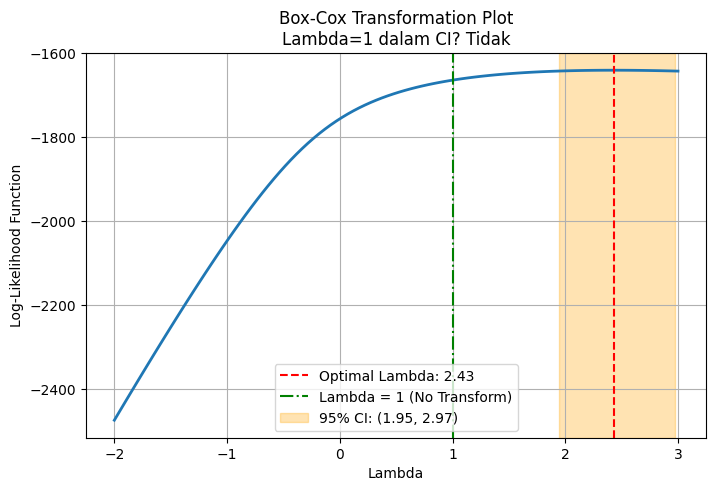

LAPORAN EKSPLORASI DATA DERET WAKTU (EDA)

[1] Uji Stasioneritas dalam Nilai Tengah:
  - ADF Test (H0: Tidak stasioner): p-value = 0.9213 -> Tidak Stasioner
  - KPSS Test (H0: Stasioner): p-value = 0.1000 -> Stasioner

[2] Uji Stasioneritas dalam Ragam (Box-Cox Transformation):
  - Nilai Lambda Optimum: 2.4282
  - 95% Confidence Interval: (1.9490, 2.9734)
  - Apakah Lambda=1 dalam CI? Tidak (Perlu transformasi)


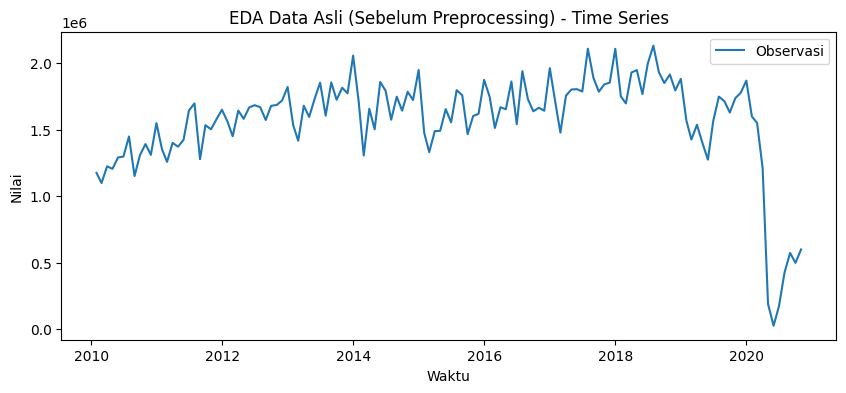

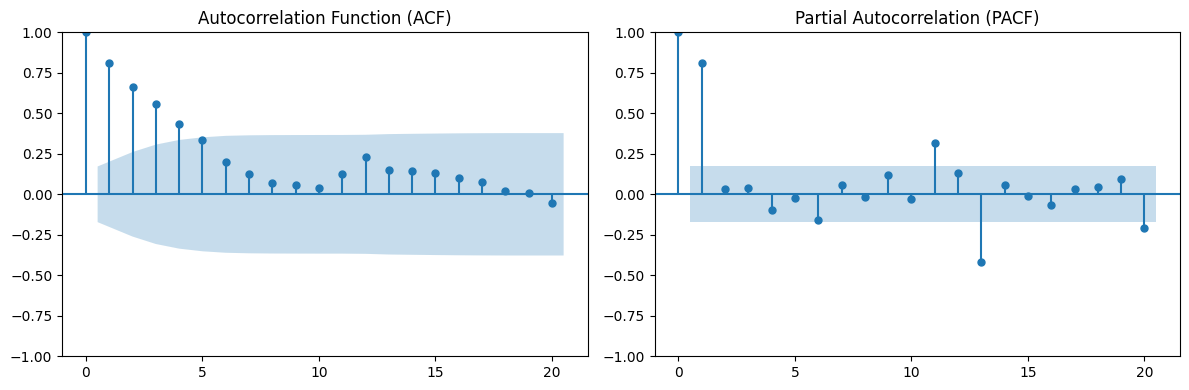

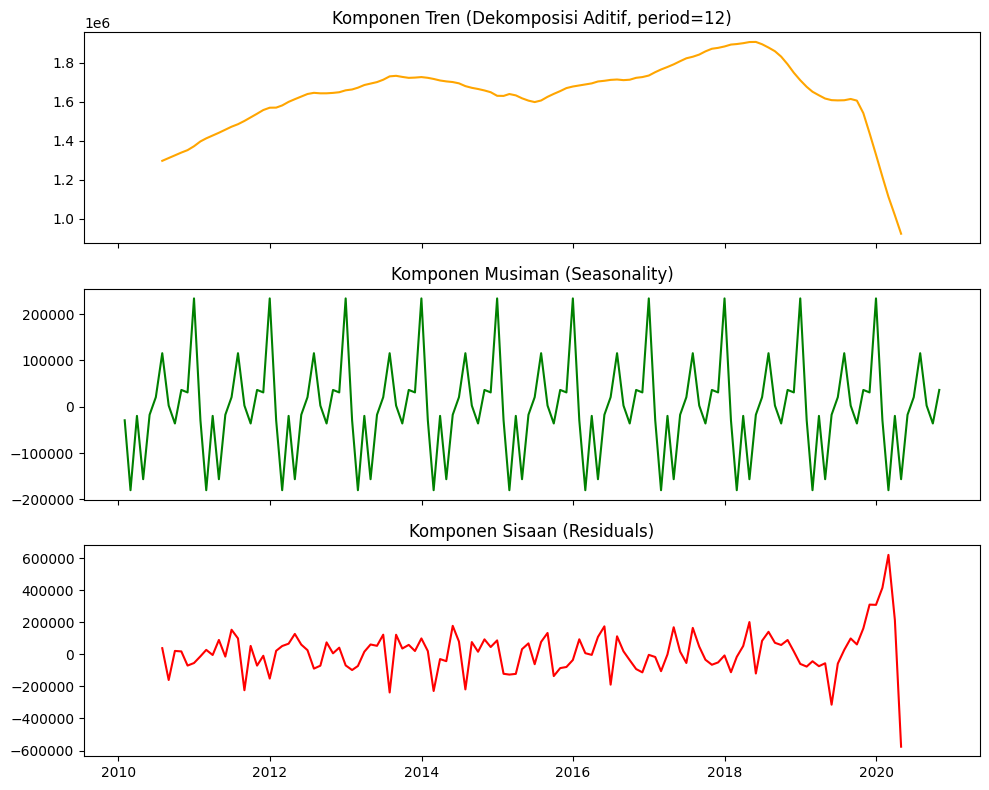

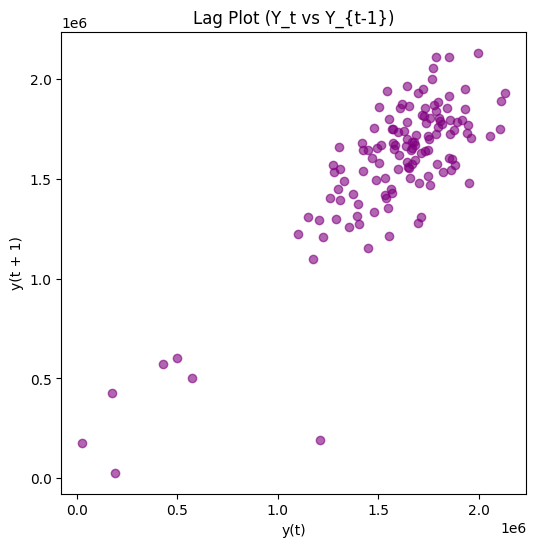


[ TAHAP 2: ESTIMASI PARAMETER (EACF) ]


,MA 0,MA 1,MA 2,MA 3,MA 4,MA 5,MA 6,MA 7
AR 0,x,o,o,o,o,x,x,o
AR 1,x,o,o,o,o,o,o,o
AR 2,o,o,o,o,o,o,o,o
AR 3,o,o,o,o,o,o,x,x
AR 4,o,o,o,o,o,o,x,o
AR 5,o,o,o,o,o,o,o,o
AR 6,o,o,o,o,o,o,o,o
AR 7,o,o,o,o,o,o,o,o


 -> Kandidat: [(5, 0), (6, 0), (5, 1), (7, 0), (6, 1)]

[ REKAPITULASI METRIK ]


,Order,AIC,BIC,AICc,HQIC,LOGLIKE
0,"(5, 2, 0)",8035.898450,8053.010631,8036.592665,8042.851216,-4011.949225
1,"(6, 2, 0)",8026.155867,8046.120078,8027.089200,8034.267428,-4006.077933
2,"(5, 2, 1)",8014.413829,8034.378041,8015.347163,8022.525390,-4000.206915
3,"(7, 2, 0)",8026.510744,8049.326986,8027.720828,8035.781100,-4005.255372
4,"(6, 2, 1)",8011.896724,8034.712966,8013.106808,8021.167080,-3997.948362



[ TAHAP 3: DIAGNOSTIK SISAAN (KOMPREHENSIF) ]

>> MODEL: ARIMA(6, 2, 1) (Dipilih oleh: AIC, AICc, HQIC, LOGLIKE)
--------------------------------------------------------------------------------
1. UJI AUTOKORELASI (Ljung-Box Test)
   [H0: Residual saling bebas | H1: Terdapat autokorelasi]
   - Setup      : Lags=12, Model_DF=7
   - Statistik  : Q = 66.5835, P-Value = 0.0000
   - Kesimpulan : TOLAK H0 -> Terdapat sisaan autokorelasi (Gagal)

2. UJI NORMALITAS (Shapiro-Wilk & Jarque-Bera)
   [H0: Residual berdistribusi normal | H1: Residual tidak berdistribusi normal]
   - Shapiro-W  : W = 0.9934, P-Value = 0.8160 -> GAGAL TOLAK H0
   - Jarque-Bera: JB = 0.1246, P-Value = 0.9396 -> GAGAL TOLAK H0
   - Momen      : Skewness = -0.0250, Kurtosis = 2.8556

3. UJI HOMOSKEDASTISITAS (ARCH-LM & Breusch-Pagan)
   [H0: Varians residual konstan | H1: Varians residual tidak konstan (Heteroskedastisitas)]
   - ARCH-LM    (Lags=10): LM = 3.6265, P-Value = 0.9626 -> GAGAL TOLAK H0
   - Breusch-Pagan (

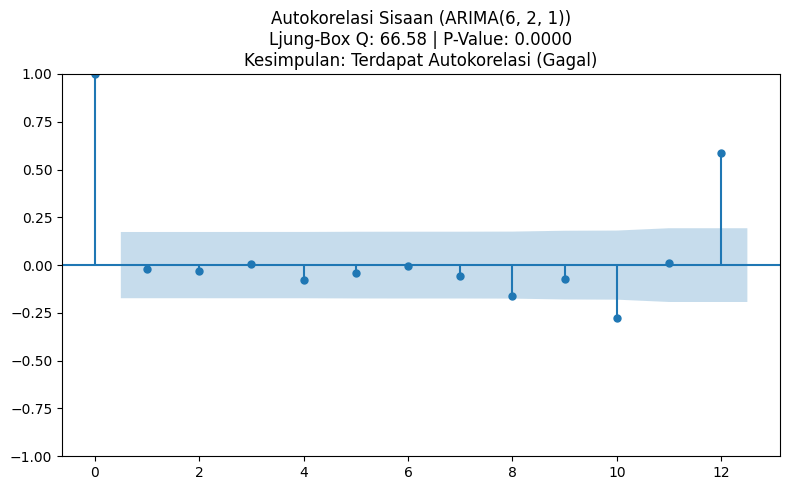

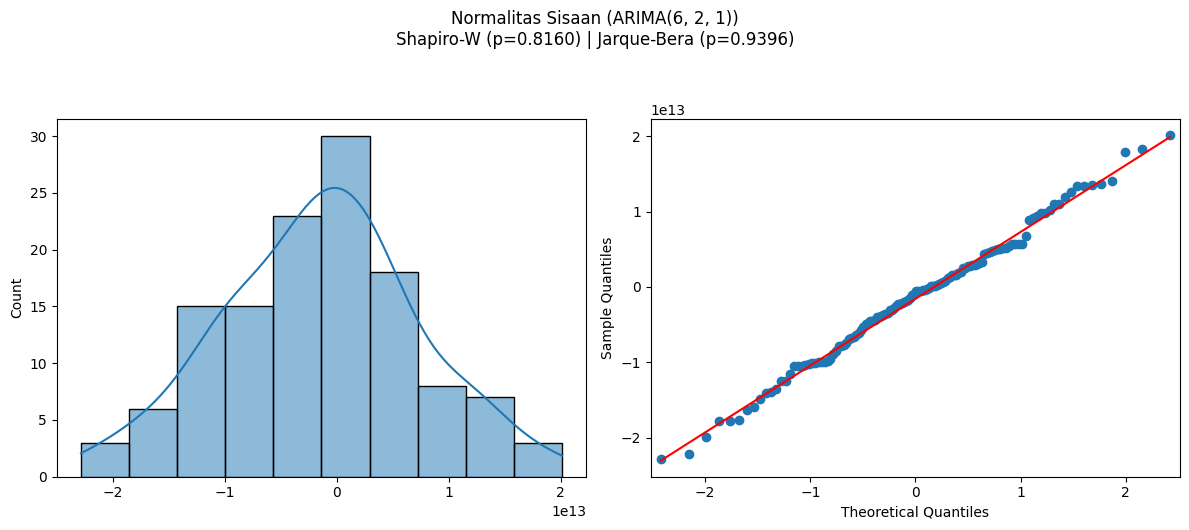

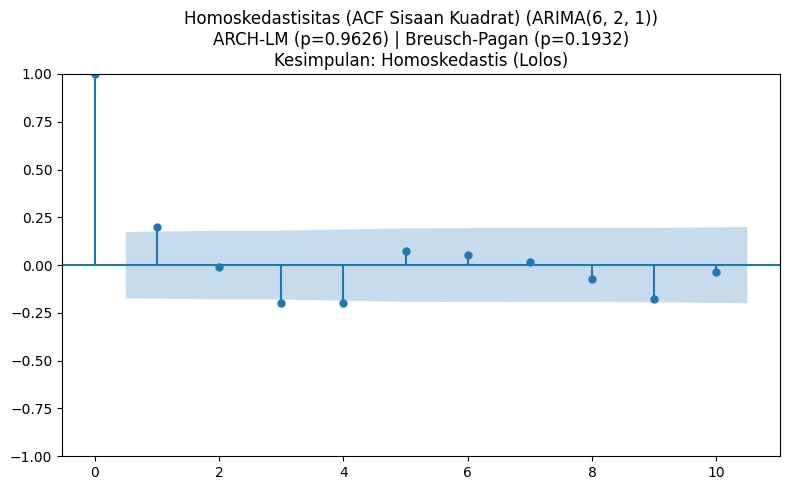

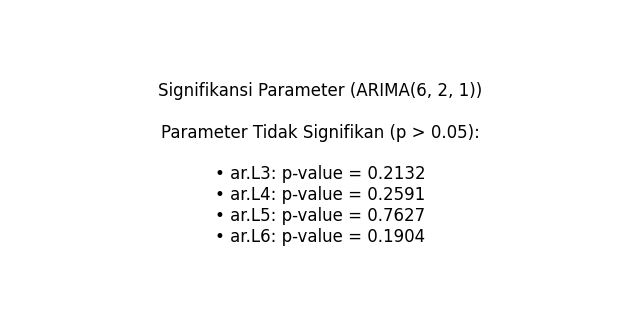


>> MODEL: ARIMA(5, 2, 1) (Dipilih oleh: BIC)
--------------------------------------------------------------------------------
1. UJI AUTOKORELASI (Ljung-Box Test)
   [H0: Residual saling bebas | H1: Terdapat autokorelasi]
   - Setup      : Lags=11, Model_DF=6
   - Statistik  : Q = 18.0063, P-Value = 0.0029
   - Kesimpulan : TOLAK H0 -> Terdapat sisaan autokorelasi (Gagal)

2. UJI NORMALITAS (Shapiro-Wilk & Jarque-Bera)
   [H0: Residual berdistribusi normal | H1: Residual tidak berdistribusi normal]
   - Shapiro-W  : W = 0.9935, P-Value = 0.8200 -> GAGAL TOLAK H0
   - Jarque-Bera: JB = 0.2223, P-Value = 0.8948 -> GAGAL TOLAK H0
   - Momen      : Skewness = 0.1004, Kurtosis = 3.0371

3. UJI HOMOSKEDASTISITAS (ARCH-LM & Breusch-Pagan)
   [H0: Varians residual konstan | H1: Varians residual tidak konstan (Heteroskedastisitas)]
   - ARCH-LM    (Lags=10): LM = 2.7551, P-Value = 0.9866 -> GAGAL TOLAK H0
   - Breusch-Pagan (Trend): LM = 2.2141, P-Value = 0.1368 -> GAGAL TOLAK H0
   - Kesimpul

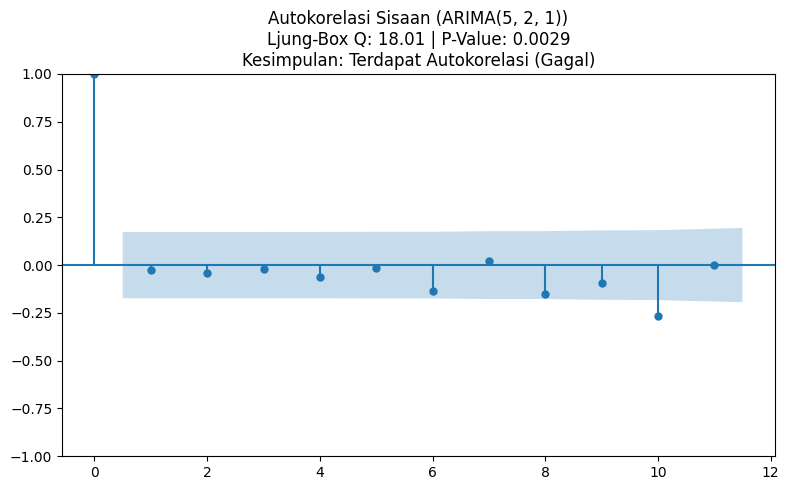

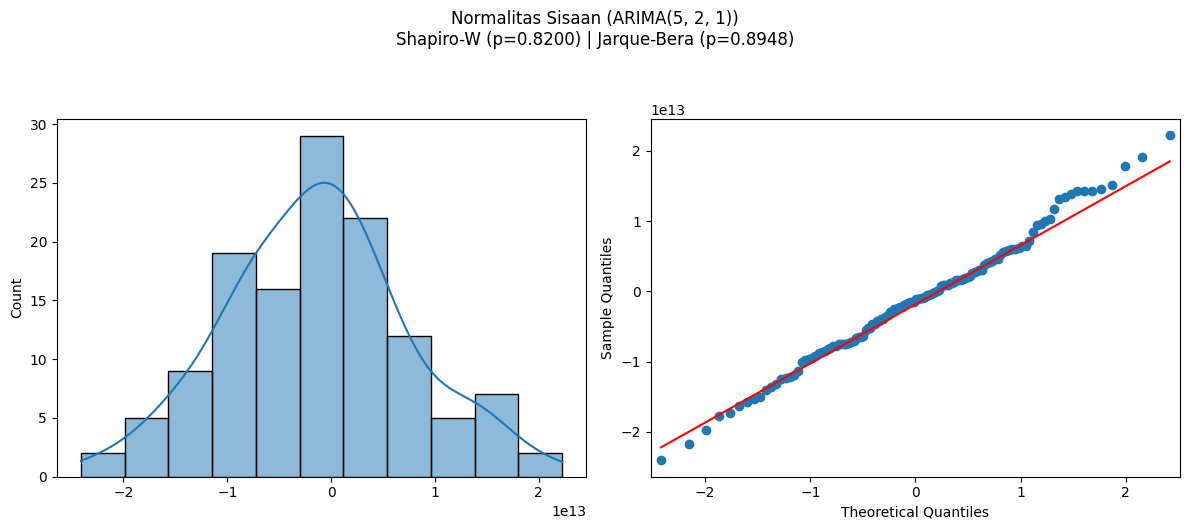

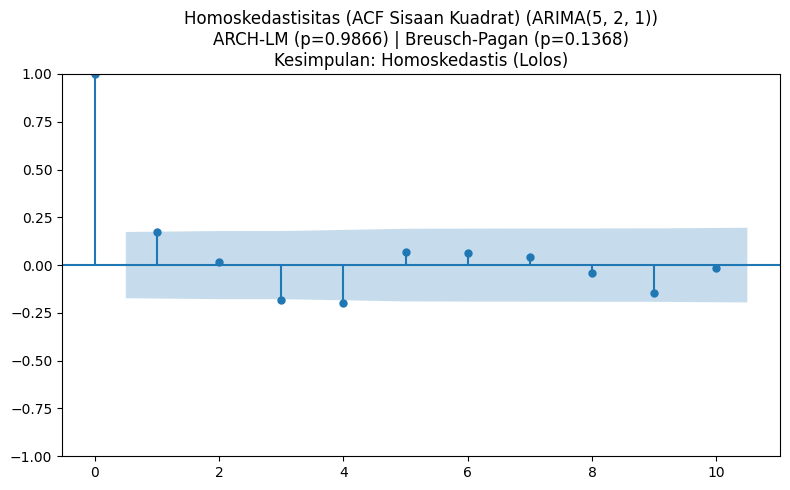

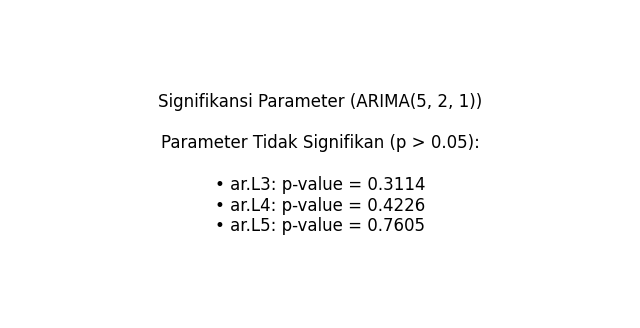


[-] Tidak ada model yang lolos semua uji diagnostik pada attempt 1.
 -> Mengekspansi ruang pencarian (max_p, max_q)...

################################################################################
--- ATTEMPT 2 (max_p=14, max_q=14) ---
################################################################################

[ TAHAP 0: PREPROCESSING ]
 -> Outliers di-cap berbasis IQR (7 titik).
 -> Box-Cox diterapkan (Lambda=2.2415).

[ TAHAP 1: KESTASIONERAN & IDENTIFIKASI ]
 -> Diferensiasi Terpilih: d = 2
 -> Adaptive Bounds: max_p=14, max_q=14

[ TAHAP 2: ESTIMASI PARAMETER (EACF) ]


,MA 0,MA 1,MA 2,MA 3,MA 4,MA 5,MA 6,MA 7,MA 8,MA 9,MA 10,MA 11,MA 12,MA 13,MA 14
AR 0,x,o,o,o,o,x,x,o,x,x,x,x,x,o,o
AR 1,x,o,o,o,o,o,o,o,o,x,x,x,x,o,o
AR 2,o,o,o,o,o,o,o,o,o,x,x,x,o,o,o
AR 3,o,o,o,o,o,o,x,x,x,x,x,x,o,o,o
AR 4,o,o,o,o,o,o,x,o,o,x,o,x,o,o,o
AR 5,o,o,o,o,o,o,o,o,x,x,o,x,o,o,o
AR 6,o,o,o,o,o,o,o,o,o,x,o,x,o,o,o
AR 7,o,o,o,o,o,o,o,o,o,x,o,x,o,o,o
AR 8,o,o,o,o,o,o,o,o,o,o,o,x,o,o,o
AR 9,o,x,o,o,x,o,x,o,o,o,o,x,o,o,o


 -> Kandidat: [(12, 0), (11, 1), (13, 0), (12, 1), (11, 2)]

[ REKAPITULASI METRIK ]


,Order,AIC,BIC,AICc,HQIC,LOGLIKE
0,"(12, 2, 0)",7946.314132,7983.390525,7949.507114,7961.378460,-3960.157066
1,"(11, 2, 1)",7938.051630,7975.128024,7941.244613,7953.115958,-3956.025815
2,"(13, 2, 0)",7942.644879,7982.573303,7946.361694,7958.868002,-3957.322440
3,"(12, 2, 1)",7937.314527,7977.242951,7941.031342,7953.537650,-3954.657264
4,"(11, 2, 2)",7938.303036,7978.231460,7942.019851,7954.526159,-3955.151518



[ TAHAP 3: DIAGNOSTIK SISAAN (KOMPREHENSIF) ]

>> MODEL: ARIMA(12, 2, 1) (Dipilih oleh: AIC, AICc, LOGLIKE)
--------------------------------------------------------------------------------
1. UJI AUTOKORELASI (Ljung-Box Test)
   [H0: Residual saling bebas | H1: Terdapat autokorelasi]
   - Setup      : Lags=18, Model_DF=13
   - Statistik  : Q = 6.2677, P-Value = 0.2810
   - Kesimpulan : GAGAL TOLAK H0 -> Residual saling bebas (Lolos)

2. UJI NORMALITAS (Shapiro-Wilk & Jarque-Bera)
   [H0: Residual berdistribusi normal | H1: Residual tidak berdistribusi normal]
   - Shapiro-W  : W = 0.9930, P-Value = 0.7815 -> GAGAL TOLAK H0
   - Jarque-Bera: JB = 0.9916, P-Value = 0.6091 -> GAGAL TOLAK H0
   - Momen      : Skewness = -0.0706, Kurtosis = 3.4074

3. UJI HOMOSKEDASTISITAS (ARCH-LM & Breusch-Pagan)
   [H0: Varians residual konstan | H1: Varians residual tidak konstan (Heteroskedastisitas)]
   - ARCH-LM    (Lags=10): LM = -0.0084, P-Value = 1.0000 -> GAGAL TOLAK H0
   - Breusch-Pagan (Trend

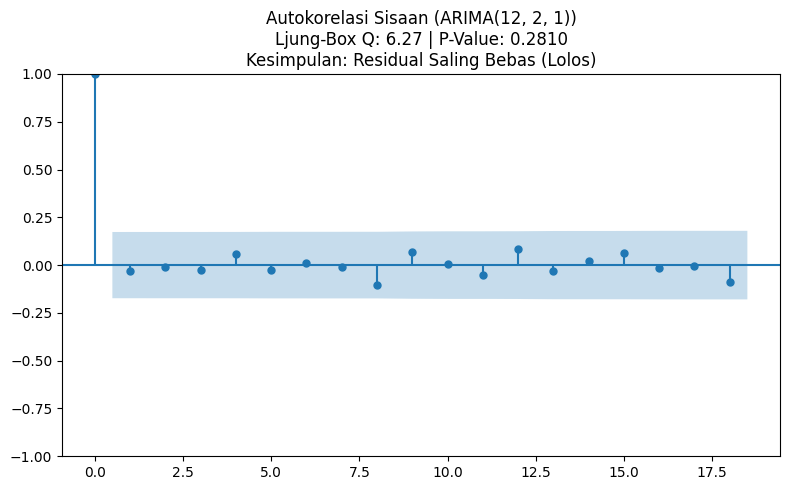

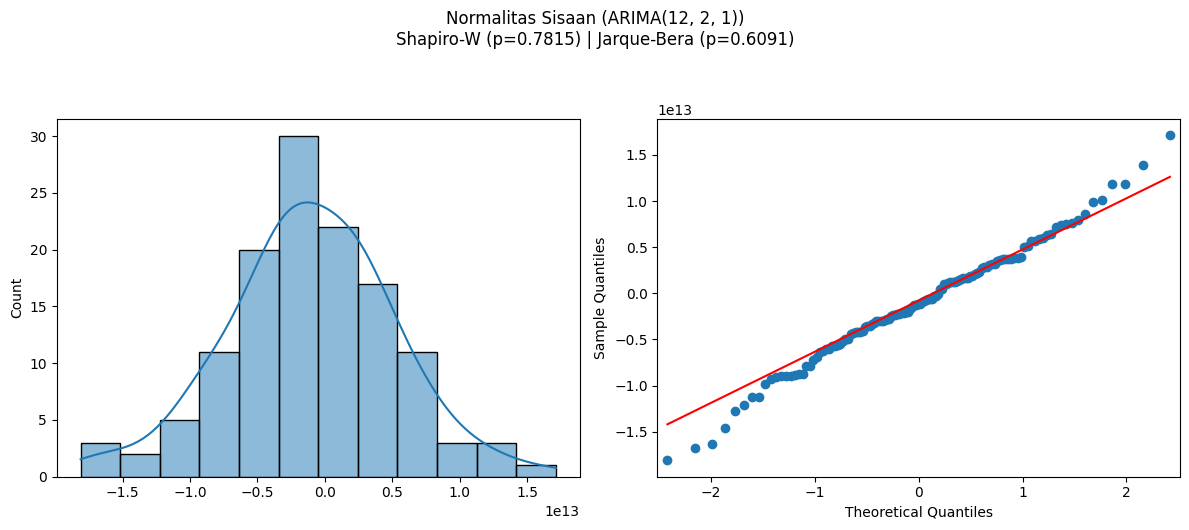

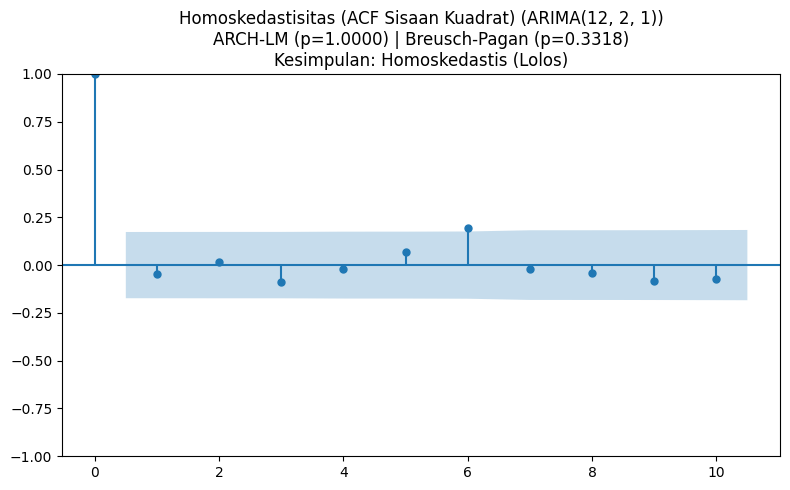

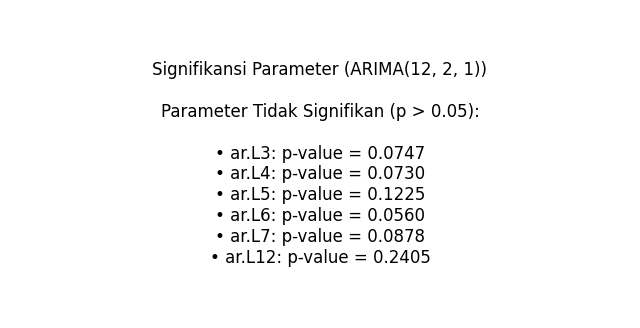


>> MODEL: ARIMA(11, 2, 1) (Dipilih oleh: BIC, HQIC)
--------------------------------------------------------------------------------
1. UJI AUTOKORELASI (Ljung-Box Test)
   [H0: Residual saling bebas | H1: Terdapat autokorelasi]
   - Setup      : Lags=17, Model_DF=12
   - Statistik  : Q = 5.6103, P-Value = 0.3460
   - Kesimpulan : GAGAL TOLAK H0 -> Residual saling bebas (Lolos)

2. UJI NORMALITAS (Shapiro-Wilk & Jarque-Bera)
   [H0: Residual berdistribusi normal | H1: Residual tidak berdistribusi normal]
   - Shapiro-W  : W = 0.9943, P-Value = 0.8869 -> GAGAL TOLAK H0
   - Jarque-Bera: JB = 0.5605, P-Value = 0.7556 -> GAGAL TOLAK H0
   - Momen      : Skewness = -0.1144, Kurtosis = 3.2296

3. UJI HOMOSKEDASTISITAS (ARCH-LM & Breusch-Pagan)
   [H0: Varians residual konstan | H1: Varians residual tidak konstan (Heteroskedastisitas)]
   - ARCH-LM    (Lags=10): LM = 0.6322, P-Value = 1.0000 -> GAGAL TOLAK H0
   - Breusch-Pagan (Trend): LM = 1.1011, P-Value = 0.2940 -> GAGAL TOLAK H0
   - K

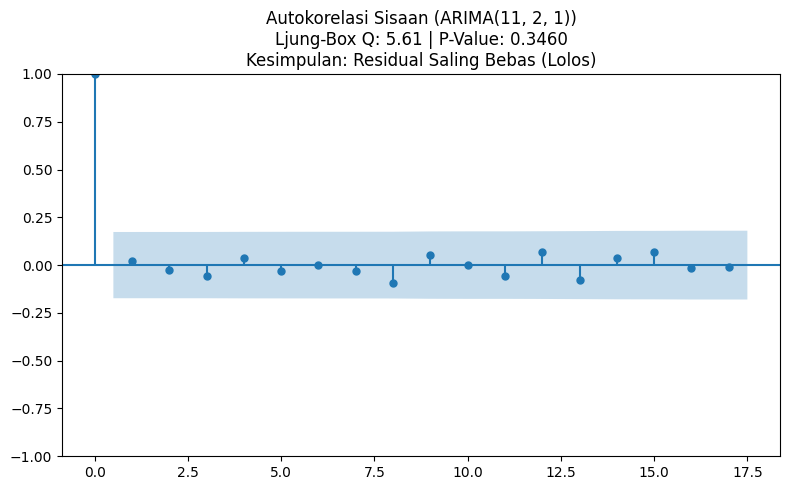

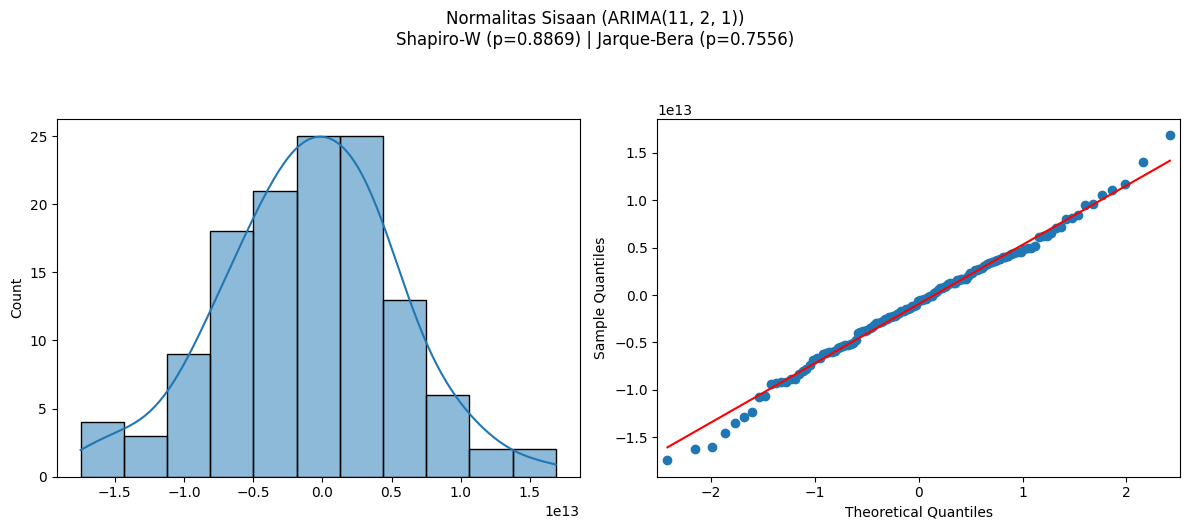

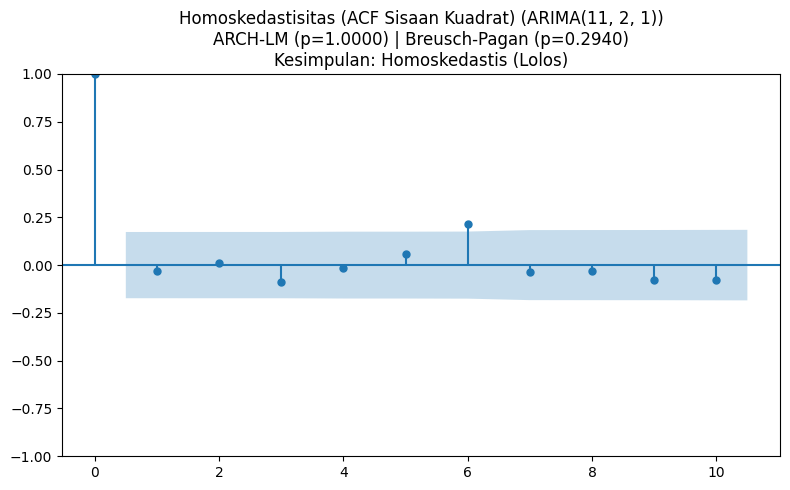

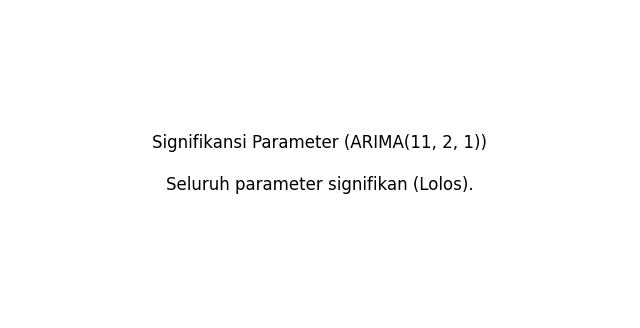


[+] Ditemukan model yang lolos uji diagnostik kritikal (Autokorelasi, Homoskedastisitas, Signifikansi Parameter)!


In [9]:
analyzer = None
prev_candidates = None

for attempt in range(MAX_RETRIES):
    current_p = BASE_P + attempt * 7
    current_q = BASE_Q + attempt * 7

    print(f"\n{'#' * 80}")
    print(f"--- ATTEMPT {attempt + 1} (max_p={current_p}, max_q={current_q}) ---")
    print(f"{'#' * 80}")

    analyzer = BoxJenkinsAnalyzer(
        DynamicTimeSeriesPreprocessor(auto_boxcox=True),
        max_d=MAX_D, max_p=current_p, max_q=current_q,
        output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS, seasonal_period=SEASONAL_PERIOD,
    )
    analyzer.run_pipeline(train_data, show_eda=(attempt == 0))

    if analyzer.candidates == prev_candidates:
        print("\n[-] Kandidat sama dengan attempt sebelumnya; perluasan ruang pencarian tidak menambah model baru.")
        break
    prev_candidates = analyzer.candidates

    if analyzer.diagnostics():
        print("\n[+] Ditemukan model yang lolos uji diagnostik kritikal (Autokorelasi, Homoskedastisitas, Signifikansi Parameter)!")
        break

    print(f"\n[-] Tidak ada model yang lolos semua uji diagnostik pada attempt {attempt + 1}.")
    if attempt < MAX_RETRIES - 1:
        print(" -> Mengekspansi ruang pencarian (max_p, max_q)...")
    else:
        print(" -> Batas percobaan maksimal tercapai. Melanjutkan dengan model terbaik yang ada.")

Dengan mempertimbangkan diagnostik residual dan signifikansi parameter secara simultan, model yang memenuhi kriteria diagnostik kritikal adalah ARIMA(11,2,1). Model ini menghasilkan residual yang:

bebas autokorelasi, Ljung–Box p-value = 0,3460;
berdistribusi normal, berdasarkan Shapiro–Wilk dan Jarque–Bera;
homoskedastis, berdasarkan ARCH-LM dan Breusch–Pagan; dan
seluruh parameternya signifikan.

## 5. Evaluasi


[ TAHAP 4: EVALUASI TESTING OUT-OF-SAMPLE ]
   [!] ARIMA(11, 2, 1) (BIC, HQIC) menghasilkan forecast NaN, dilewati.


,Kriteria,Model,MAE,RMSE,MAPE (%),sMAPE (%),MASE
0,"AIC, AICc, LOGLIKE","ARIMA(12, 2, 1)",395917.1985,469046.8624,66.1588,44.9342,2.495


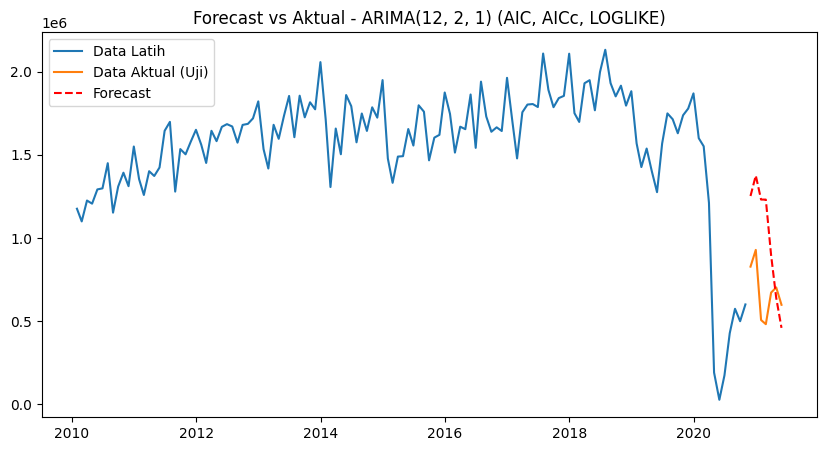

In [10]:
hasil_uji = analyzer.evaluate(test_data, plot=True)

Tahap 1 – Seleksi berdasarkan diagnostik

ARIMA(11,2,1) → residual memenuhi kriteria dan parameter signifikan.

ARIMA(12,2,1) → residual memenuhi diagnostik, tetapi beberapa parameter tidak signifikan.

Tahap 2 – Evaluasi forecasting

ARIMA(11,2,1) → forecast NaN, sehingga tidak bisa dievaluasi.

ARIMA(12,2,1) → forecast tersedia, tetapi error forecasting cukup besar.

### Investigating NaN Forecast for ARIMA(11,2,1)

We will now explicitly retrieve the ARIMA(11,2,1) model, perform its forecast on the test data length, and inspect the raw predicted values and the effect of the inverse transformation. This should help us pinpoint where the `NaN` values originate.

In [11]:
print('\n--- Debugging ARIMA(11,2,1) Forecast ---')

# Retrieve the ARIMA(11,2,1) model (selected by BIC or HQIC)
model_11_2_1 = analyzer.best_models['BIC'] # Or 'HQIC'

# Get the raw forecast from the model
raw_forecast = model_11_2_1.get_forecast(steps=len(test_data))
predicted_mean_raw = raw_forecast.predicted_mean

print('\nRaw predicted_mean from get_forecast:')
display(predicted_mean_raw)

# Attempt inverse transform
try:
    y_pred_transformed = analyzer.preprocessor.inverse_transform(predicted_mean_raw)
    print('\nInverse transformed forecast:')
    display(pd.Series(y_pred_transformed, index=test_data.index))
except Exception as e:
    print(f'\nError during inverse transformation: {e}')
    y_pred_transformed = np.full_like(predicted_mean_raw, np.nan)

# Check for NaN values in the raw forecast
if np.isnan(predicted_mean_raw).any():
    print('\nConclusion: The raw predicted_mean from the ARIMA model contains NaN values.')
elif np.isnan(y_pred_transformed).any():
    print('\nConclusion: NaN values appeared after the inverse transformation.')
else:
    print("\nConclusion: No NaN values found in raw or transformed forecast. The issue might be specific to the `evaluate` method's execution environment or other factors.")

print('\n--- End Debugging ---')


--- Debugging ARIMA(11,2,1) Forecast ---

Raw predicted_mean from get_forecast:


,predicted_mean
2020-11-30,2.078407e+13
2020-12-31,2.496250e+13
2021-01-31,1.918199e+13
2021-02-28,1.782031e+13
2021-03-31,7.412822e+12
2021-04-30,1.275629e+12
2021-05-31,-1.411900e+12



Inverse transformed forecast:


,0
Waktu,
2020-11-30,1.252287e+06
2020-12-31,1.358927e+06
2021-01-31,1.208265e+06
2021-02-28,1.169219e+06
2021-03-31,7.905958e+05
2021-04-30,3.605807e+05
2021-05-31,NaN



Conclusion: NaN values appeared after the inverse transformation.

--- End Debugging ---


In [12]:
hasil_cv = analyzer.evaluate_cv(initial_ratio=0.8, horizon=1)


[ TAHAP 4.5: ROLLING CROSS-VALIDATION ]


,Kriteria,Model,Folds,Avg MAE,Avg RMSE,Avg MAPE (%),Avg MASE
0,AIC,"ARIMA(12, 2, 1)",26,284159.2238,284159.2238,181.4756,1.8204
1,BIC,"ARIMA(11, 2, 1)",25,296939.2950,296939.2950,192.7718,1.9020
2,AICc,"ARIMA(12, 2, 1)",26,284159.2238,284159.2238,181.4756,1.8204
3,HQIC,"ARIMA(11, 2, 1)",25,296939.2950,296939.2950,192.7718,1.9020
4,LOGLIKE,"ARIMA(12, 2, 1)",26,284159.2238,284159.2238,181.4756,1.8204


Hasil rolling cross-validation menunjukkan bahwa:

ARIMA(12,2,1) memberikan nilai rata-rata MAE dan MASE yang lebih kecil dibandingkan ARIMA(11,2,1), sedangkan ARIMA(11,2,1) memiliki nilai error yang lebih besar pada rolling validation.

## 6. Forecast ke depan

Model di-refit pada seluruh data (latih + uji) agar forecast dimulai tepat setelah observasi terakhir.


[ TAHAP 5: FUTURE FORECASTING ]
 -> Model di-refit pada seluruh data (latih + uji).


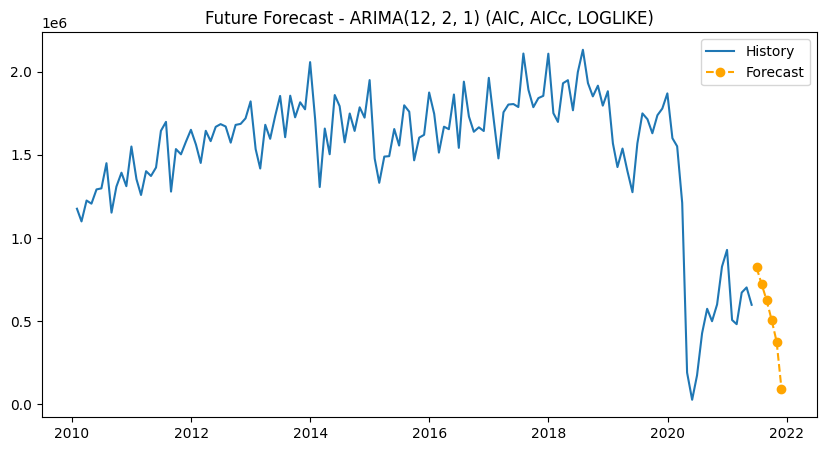

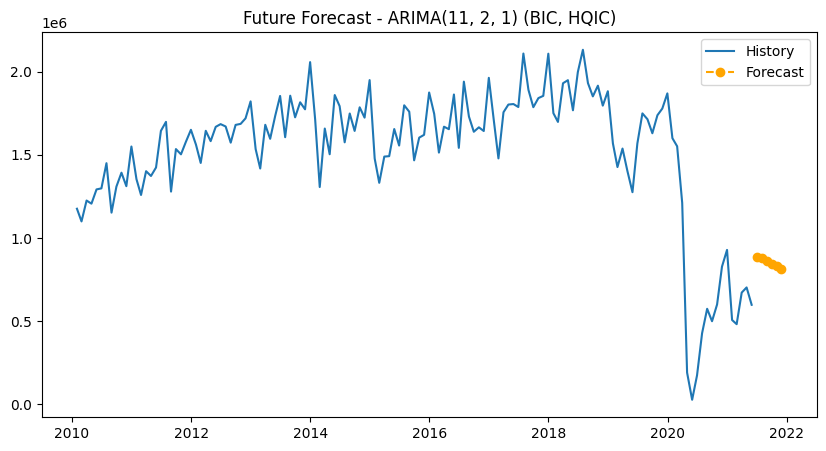

,"AIC, AICc, LOGLIKE | ARIMA(12, 2, 1)","BIC, HQIC | ARIMA(11, 2, 1)"
2021-06-30,823126.06,887740.60
2021-07-31,723777.96,877277.28
2021-08-31,624591.94,862707.84
2021-09-30,509655.93,842913.81
2021-10-31,377716.38,830707.14
2021-11-30,92650.86,812896.00


In [13]:
hasil_forecast = analyzer.forecast(steps=6, full_series=serie)

Model Terbaik ARIMA (12,2,1)